In [ ]:
# Step 1: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
# Step 2: Load Data
plant1 = pd.read_csv('/content/drive/MyDrive/Final_Merged_Plant_1.csv')
plant2 = pd.read_csv('/content/drive/MyDrive/Final_Merged_Plant_2.csv')

plant1['DATE_TIME'] = pd.to_datetime(plant1['DATE_TIME'])
plant2['DATE_TIME'] = pd.to_datetime(plant2['DATE_TIME'])

plant1['PLANT'] = 'Plant_1'
plant2['PLANT'] = 'Plant_2'

combined_df = pd.concat([plant1, plant2], ignore_index=True)
combined_df.dropna(inplace=True)

In [ ]:
# Step 3: Exploratory Data Analysis (EDA)

# 3.1 Overview of the Dataset
print(combined_df.info())
print(combined_df.describe())

# 3.2 Missing Values Check
print(combined_df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136472 entries, 0 to 136471
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE_TIME            136472 non-null  datetime64[ns]
 1   PLANT_ID             136472 non-null  int64         
 2   SOURCE_KEY           136472 non-null  object        
 3   DC_POWER             136472 non-null  float64       
 4   AC_POWER             136472 non-null  float64       
 5   DAILY_YIELD          136472 non-null  float64       
 6   TOTAL_YIELD          136472 non-null  float64       
 7   AMBIENT_TEMPERATURE  136472 non-null  float64       
 8   MODULE_TEMPERATURE   136472 non-null  float64       
 9   IRRADIATION          136472 non-null  float64       
 10  PLANT                136472 non-null  object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 11.5+ MB
None
                           DATE_TIME      PLANT_

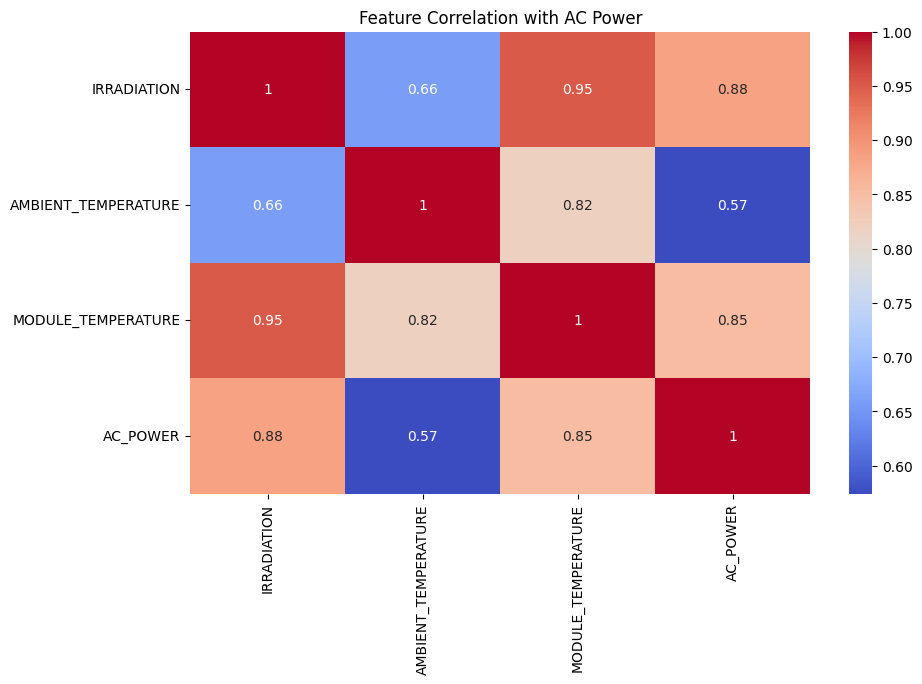

In [ ]:
# 3.3 Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(combined_df[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'AC_POWER']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with AC Power')
plt.show()

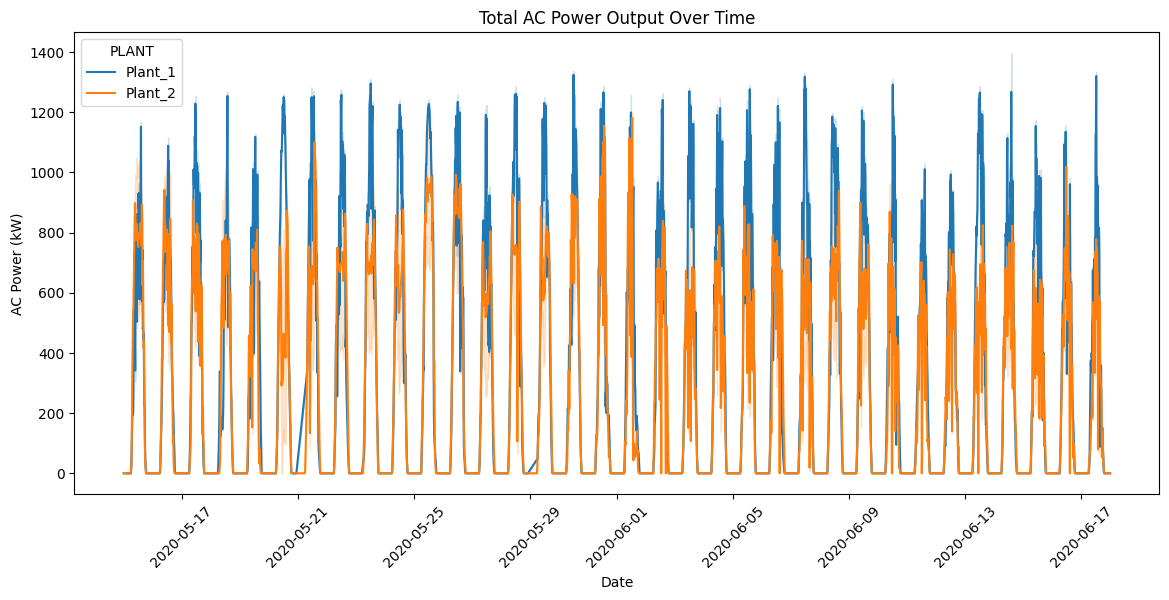

In [ ]:
# 3.4 Total Power Output over Time
plt.figure(figsize=(14,6))
sns.lineplot(data=combined_df, x='DATE_TIME', y='AC_POWER', hue='PLANT')
plt.title('Total AC Power Output Over Time')
plt.xlabel('Date')
plt.ylabel('AC Power (kW)')
plt.xticks(rotation=45)
plt.show()

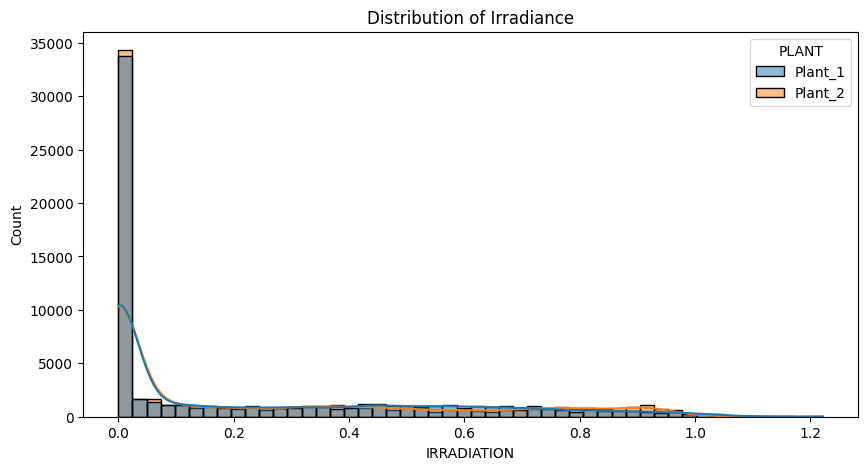

In [ ]:
# 3.5 Distribution of Irradiance
plt.figure(figsize=(10,5))
sns.histplot(data=combined_df, x='IRRADIATION', bins=50, kde=True, hue='PLANT')
plt.title('Distribution of Irradiance')
plt.show()

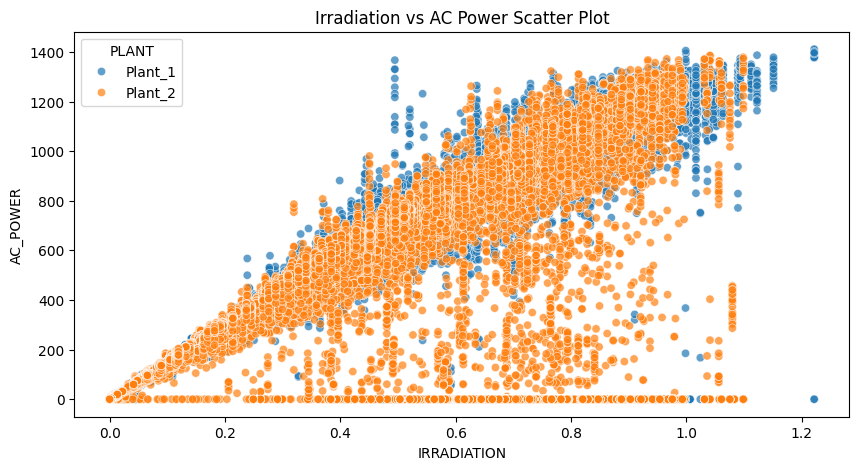

In [ ]:
# 3.6 Scatter Plot: Irradiation vs AC Power
plt.figure(figsize=(10,5))
sns.scatterplot(data=combined_df, x='IRRADIATION', y='AC_POWER', hue='PLANT', alpha=0.7)
plt.title('Irradiation vs AC Power Scatter Plot')
plt.show()

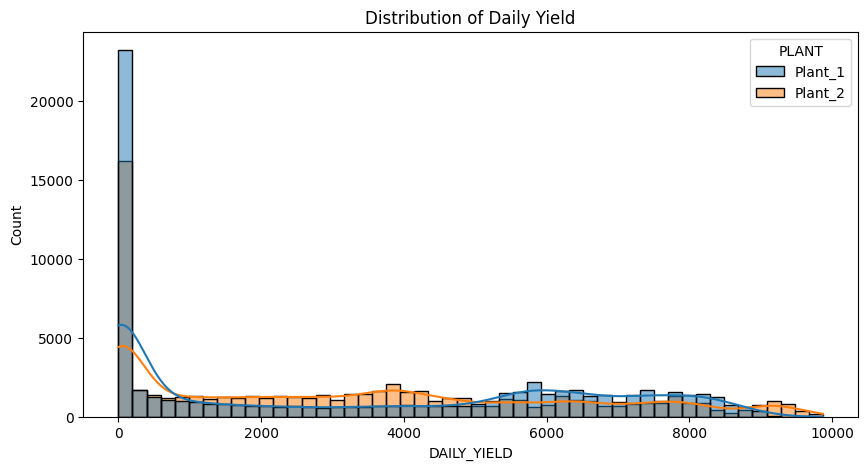

In [ ]:
# 3.7 Distribution of Daily Yield
plt.figure(figsize=(10,5))
sns.histplot(data=combined_df, x='DAILY_YIELD', bins=50, kde=True, hue='PLANT')
plt.title('Distribution of Daily Yield')
plt.show()

In [ ]:
# Step 4: Feature Selection and Scaling
features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
target = 'AC_POWER'

X = combined_df[features]
y = combined_df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Random Forest Classifier Performance:
Accuracy: 0.9552
Precision: 0.9577
Recall: 0.9552

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     13520
           1       0.84      0.88      0.86       125
           2       0.98      0.96      0.97      6841
           3       0.88      0.96      0.92      6809

    accuracy                           0.96     27295
   macro avg       0.92      0.94      0.93     27295
weighted avg       0.96      0.96      0.96     27295



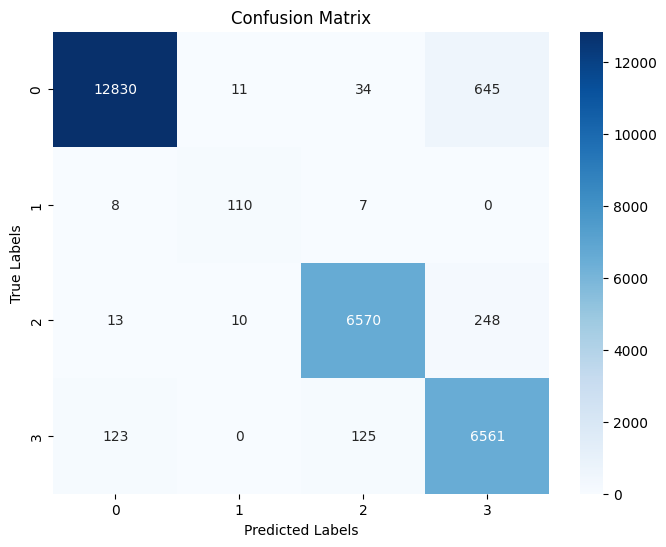

In [20]:
# Step 6: Random Forest Model
# Add to your existing imports for classification metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 6 Modified: Random Forest Classifier
# First, we need to convert the regression problem to classification
# Let's create categories for AC_POWER based on quartiles or another meaningful threshold

# Method 1: Using quartiles to create classes
q_25 = combined_df['AC_POWER'].quantile(0.25)
q_50 = combined_df['AC_POWER'].quantile(0.50)
q_75 = combined_df['AC_POWER'].quantile(0.75)

def categorize_power(power):
    if power <= q_25:
        return 0  # Low production
    elif power <= q_50:
        return 1  # Medium-low production
    elif power <= q_75:
        return 2  # Medium-high production
    else:
        return 3  # High production

# Apply the function to create categorical target
y_class = combined_df['AC_POWER'].apply(categorize_power)

# Alternative Method 2: Binary classification (if preferred)
# median = combined_df['AC_POWER'].median()
# y_class = (combined_df['AC_POWER'] > median).astype(int)  # 0: below median, 1: above median

# Split the data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42
)

# 6.1 Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_class, y_train_class)

# 6.2 Predict and Evaluate
y_pred_class = rf_classifier.predict(X_test_class)

# Calculate metrics
accuracy = accuracy_score(y_test_class, y_pred_class)
# For multi-class, we use 'weighted' average
precision = precision_score(y_test_class, y_pred_class, average='weighted')
recall = recall_score(y_test_class, y_pred_class, average='weighted')

print("\nRandom Forest Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()




Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - loss: 0.0045 - val_loss: 0.0017
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 79s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 9/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 10/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 85s 28ms/step - loss: 0.0015 - val_loss: 0.0016


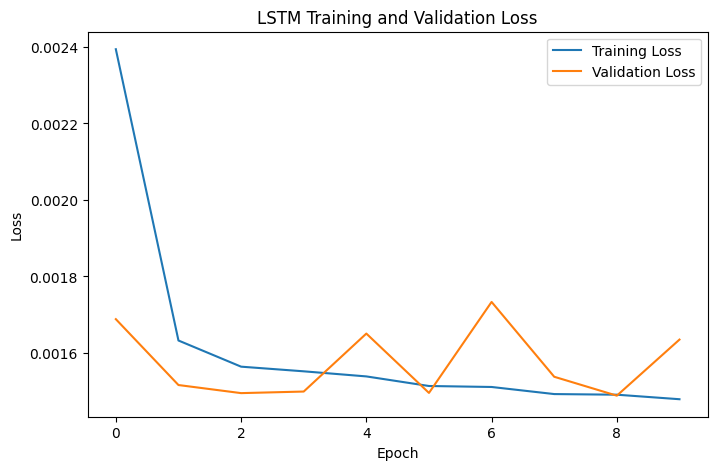

In [14]:
# Step 7: LSTM Model for Sequential Forecasting

# 7.1 Prepare Data for LSTM
lstm_df = plant1[['DATE_TIME', 'AC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
lstm_df = lstm_df.sort_values('DATE_TIME').dropna()

lstm_scaler = MinMaxScaler()
scaled_lstm_data = lstm_scaler.fit_transform(lstm_df.drop(columns='DATE_TIME'))

def create_sequences(data, sequence_length=24):
    X_seq, y_seq = [], []
    for i in range(len(data) - sequence_length):
        X_seq.append(data[i:i + sequence_length])
        y_seq.append(data[i + sequence_length][0])
    return np.array(X_seq), np.array(y_seq)

sequence_length = 24
X_lstm, y_lstm = create_sequences(scaled_lstm_data, sequence_length)

split_idx = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split_idx], X_lstm[split_idx:]
y_train_lstm, y_test_lstm = y_lstm[:split_idx], y_lstm[split_idx:]

# 7.2 Build LSTM Model
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 7.3 Train LSTM Model
history = model_lstm.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test_lstm))

# 7.4 Plot Training and Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [15]:
# Step 8: LSTM Model Evaluation

# 8.1 Predict
y_pred_lstm = model_lstm.predict(X_test_lstm)

# Inverse scaling
y_pred_actual = lstm_scaler.inverse_transform(
    np.concatenate([y_pred_lstm, np.zeros((len(y_pred_lstm), scaled_lstm_data.shape[1]-1))], axis=1)
)[:, 0]

y_test_actual = lstm_scaler.inverse_transform(
    np.concatenate([y_test_lstm.reshape(-1, 1), np.zeros((len(y_test_lstm), scaled_lstm_data.shape[1]-1))], axis=1)
)[:, 0]

print("LSTM Model Performance:")
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))
print("R² Score:", r2_score(y_test_actual, y_pred_actual))

430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
LSTM Model Performance:
MAE: 22.470310004760286
RMSE: 57.05241813666043
R² Score: 0.975696932180469


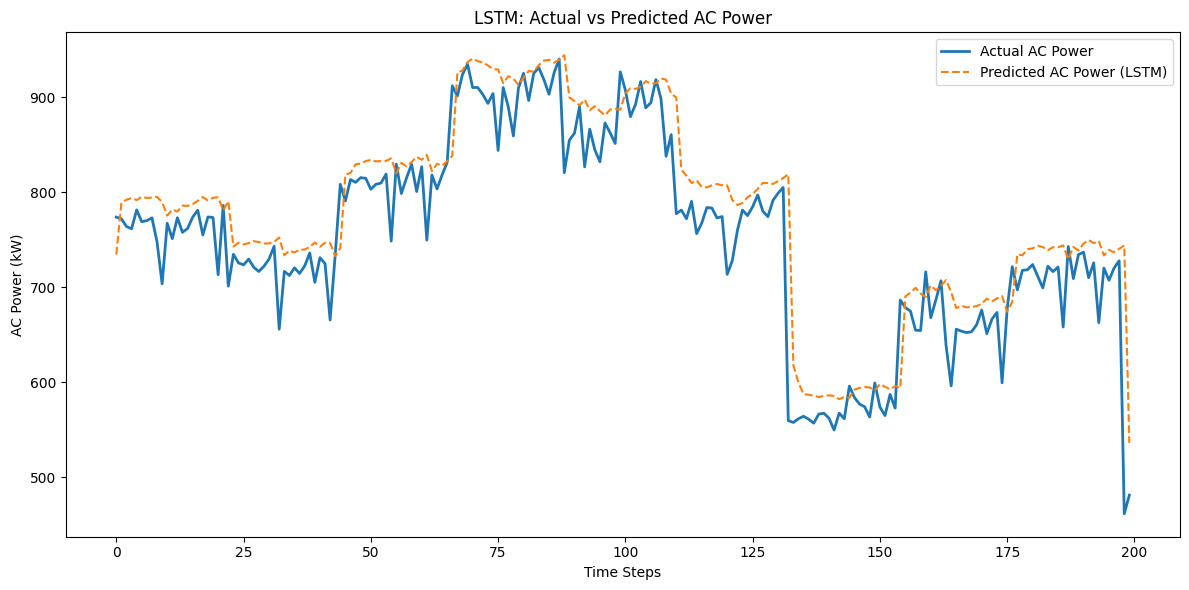

In [16]:
# Step 9: Plot LSTM Predictions vs Actual
plt.figure(figsize=(12,6))
plt.plot(y_test_actual[:200], label='Actual AC Power', linewidth=2)
plt.plot(y_pred_actual[:200], label='Predicted AC Power (LSTM)', linestyle='--')
plt.title('LSTM: Actual vs Predicted AC Power')
plt.xlabel('Time Steps')
plt.ylabel('AC Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

Training Random Forest Regressor...
Random Forest Regressor Performance:
MAE: 49.226546240661285
RMSE: 150.5683245234378
R² Score: 0.8436340539576612
Power classification thresholds: [np.float64(0.0), np.float64(3.493095238095238), np.float64(532.5685714250001)]

===== Random Forest Regressor Evaluation =====


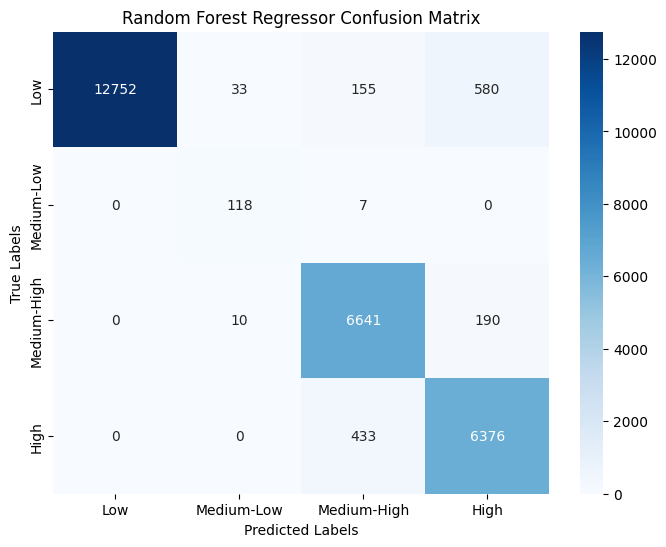

Accuracy: 0.9484
Precision: 0.9513
Recall: 0.9484

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     13520
           1       0.73      0.94      0.83       125
           2       0.92      0.97      0.94      6841
           3       0.89      0.94      0.91      6809

    accuracy                           0.95     27295
   macro avg       0.89      0.95      0.91     27295
weighted avg       0.95      0.95      0.95     27295



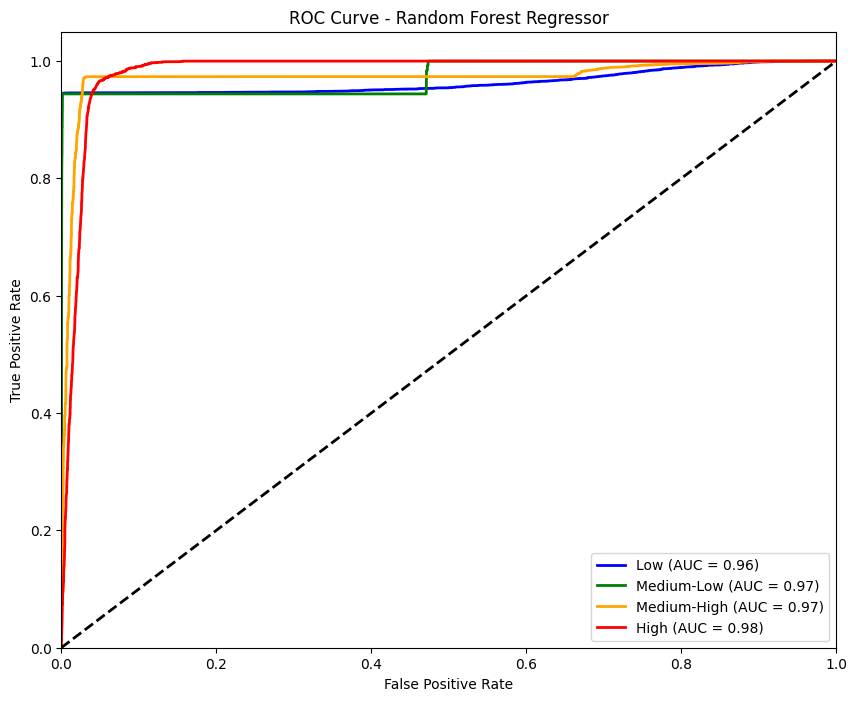


Training Random Forest Classifier...

===== Random Forest Classifier Evaluation =====


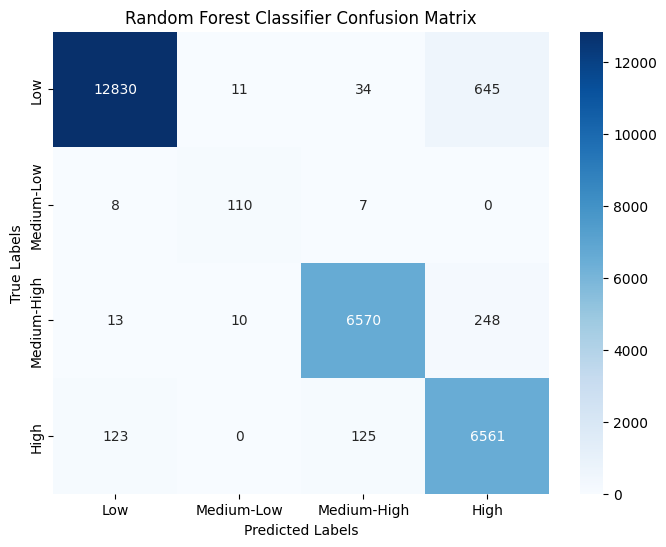

Accuracy: 0.9552
Precision: 0.9577
Recall: 0.9552

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     13520
           1       0.84      0.88      0.86       125
           2       0.98      0.96      0.97      6841
           3       0.88      0.96      0.92      6809

    accuracy                           0.96     27295
   macro avg       0.92      0.94      0.93     27295
weighted avg       0.96      0.96      0.96     27295



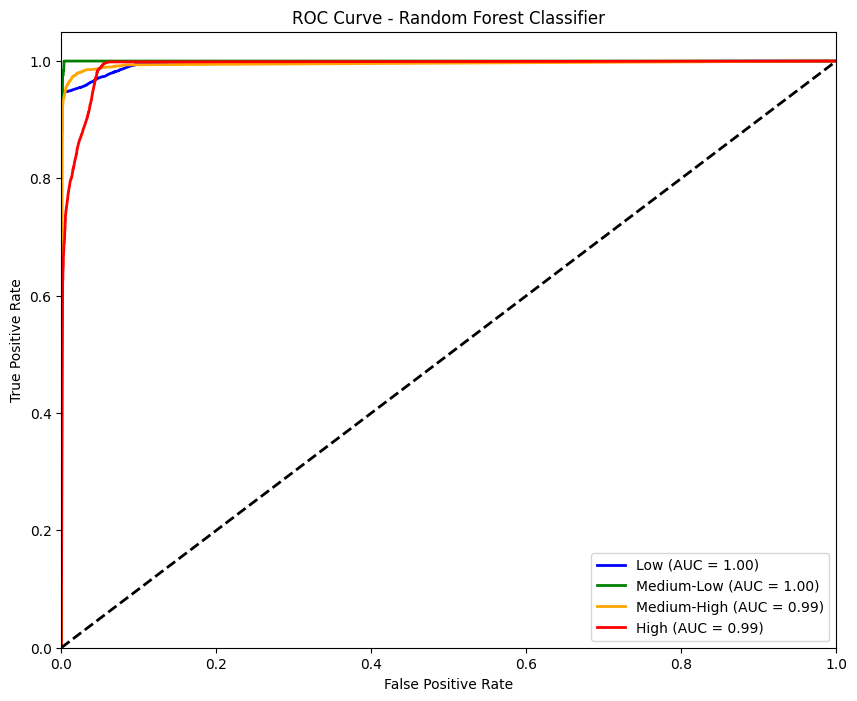

In [17]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# Define features and target
features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
target = 'AC_POWER'

X = combined_df[features]
y = combined_df[target]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data for regression
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ========= Step 1: Train Random Forest Regressor =========
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Random Forest Regressor Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² Score:", r2_score(y_test, y_pred_rf))

# ========= Step 2: Create Classification Problem =========
# Calculate quartiles for discretization
thresholds = [
    combined_df['AC_POWER'].quantile(0.25),
    combined_df['AC_POWER'].quantile(0.50),
    combined_df['AC_POWER'].quantile(0.75)
]

print(f"Power classification thresholds: {thresholds}")

# Define function to categorize power values
def categorize_power(power, thresholds):
    for i, threshold in enumerate(thresholds):
        if power <= threshold:
            return i
    return len(thresholds)

# Create categorical target for classifier
y_class = np.array([categorize_power(val, thresholds) for val in combined_df[target]])

# Split data for classification
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42
)

# Define function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    class_names = ['Low', 'Medium-Low', 'Medium-High', 'High']
    plt.xticks(np.arange(len(class_names)) + 0.5, class_names)
    plt.yticks(np.arange(len(class_names)) + 0.5, class_names)
    plt.show()
    return cm

# ========= Step 3: Evaluate Random Forest Regressor as Classifier =========
# Convert continuous predictions to classes for the Random Forest Regressor
y_test_reg_class = np.array([categorize_power(val, thresholds) for val in y_test])
y_pred_rf_class = np.array([categorize_power(val, thresholds) for val in y_pred_rf])

# Plot confusion matrix for Random Forest Regressor
print("\n===== Random Forest Regressor Evaluation =====")
cm_rf = plot_confusion_matrix(y_test_reg_class, y_pred_rf_class, 'Random Forest Regressor Confusion Matrix')

# Calculate classification metrics for regressor
accuracy_rf = accuracy_score(y_test_reg_class, y_pred_rf_class)
precision_rf = precision_score(y_test_reg_class, y_pred_rf_class, average='weighted')
recall_rf = recall_score(y_test_reg_class, y_pred_rf_class, average='weighted')

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_reg_class, y_pred_rf_class))

# For ROC curve - need to binarize for multi-class
n_classes = 4
y_test_bin = label_binarize(y_test_reg_class, classes=range(n_classes))

# Since Random Forest Regressor doesn't have predict_proba, we'll simulate probabilities
y_score_rf = np.zeros((len(y_pred_rf), n_classes))
for i in range(n_classes):
    lower = thresholds[i-1] if i > 0 else y_test.min()
    upper = thresholds[i] if i < len(thresholds) else y_test.max()
    midpoint = (lower + upper) / 2
    y_score_rf[:, i] = -np.abs(y_pred_rf - midpoint)  # Negative distance from class midpoint

# Normalize to [0,1]
mm_scaler = MinMaxScaler()
y_score_rf = mm_scaler.fit_transform(y_score_rf)

# Plot ROC curve for Random Forest Regressor
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red']
class_names = ['Low', 'Medium-Low', 'Medium-High', 'High']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Regressor')
plt.legend(loc="lower right")
plt.show()

# ========= Step 4: Train and Evaluate Random Forest Classifier =========
print("\nTraining Random Forest Classifier...")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_class, y_train_class)
y_pred_class = rf_classifier.predict(X_test_class)

# Plot confusion matrix for Random Forest Classifier
print("\n===== Random Forest Classifier Evaluation =====")
cm_rfc = plot_confusion_matrix(y_test_class, y_pred_class, 'Random Forest Classifier Confusion Matrix')

# Calculate metrics for classifier
accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class, average='weighted')
recall = recall_score(y_test_class, y_pred_class, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

# Plot ROC curve for Random Forest Classifier
y_score_rfc = rf_classifier.predict_proba(X_test_class)

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_rfc[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Classifier')
plt.legend(loc="lower right")
plt.show()

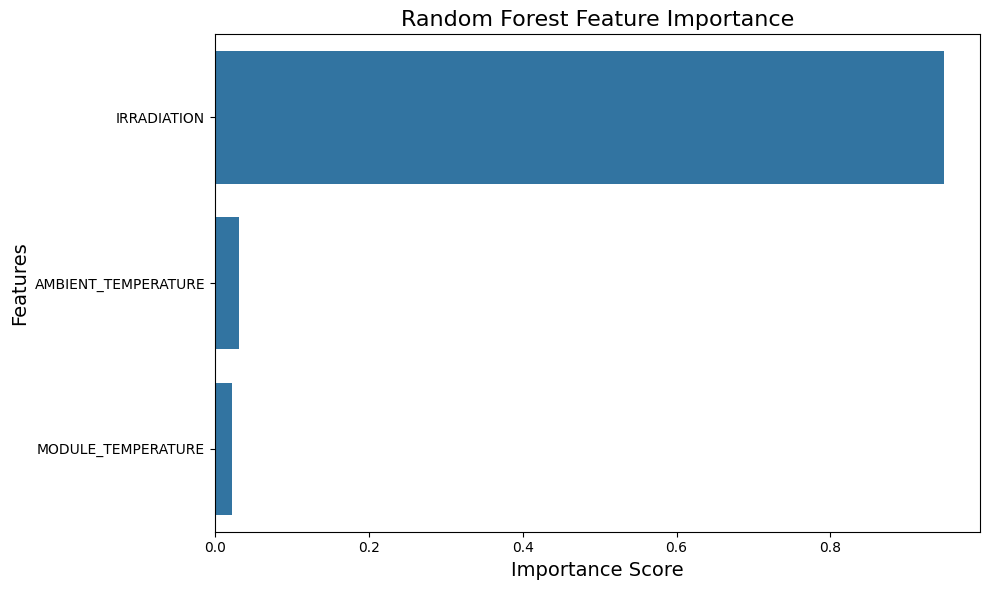

Calculating permutation importance for Random Forest...


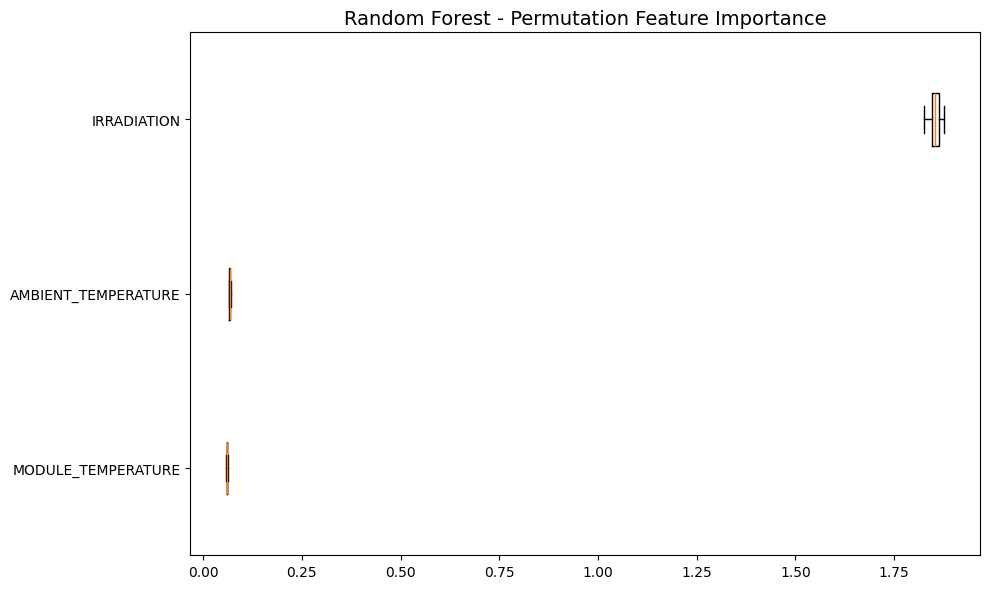

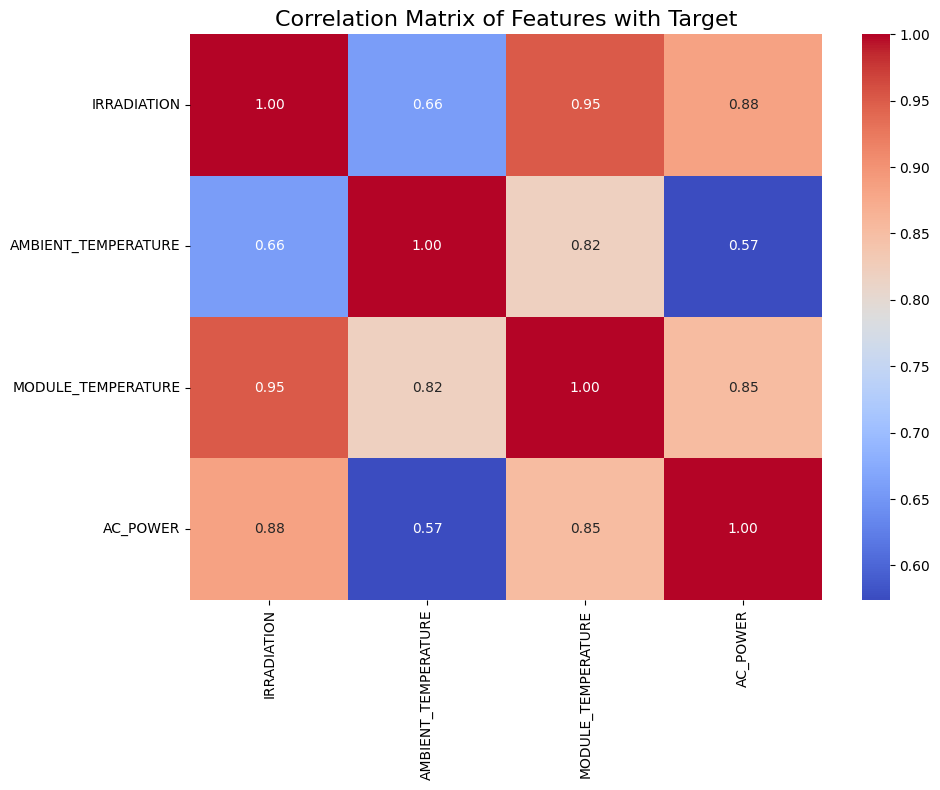


Random Forest Feature Importance Summary Table:
               Feature  Importance (Built-in)  Importance (Permutation)
0          IRRADIATION                 0.9470                    1.8523
1  AMBIENT_TEMPERATURE                 0.0313                    0.0677
2   MODULE_TEMPERATURE                 0.0217                    0.0607
Feature importance results saved to 'rf_feature_importance_results.csv'


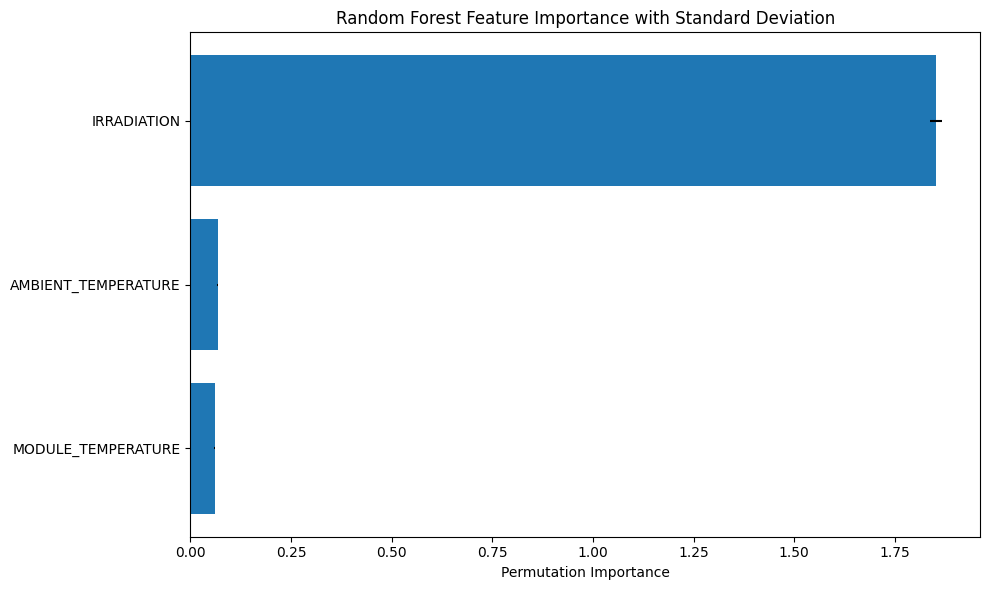

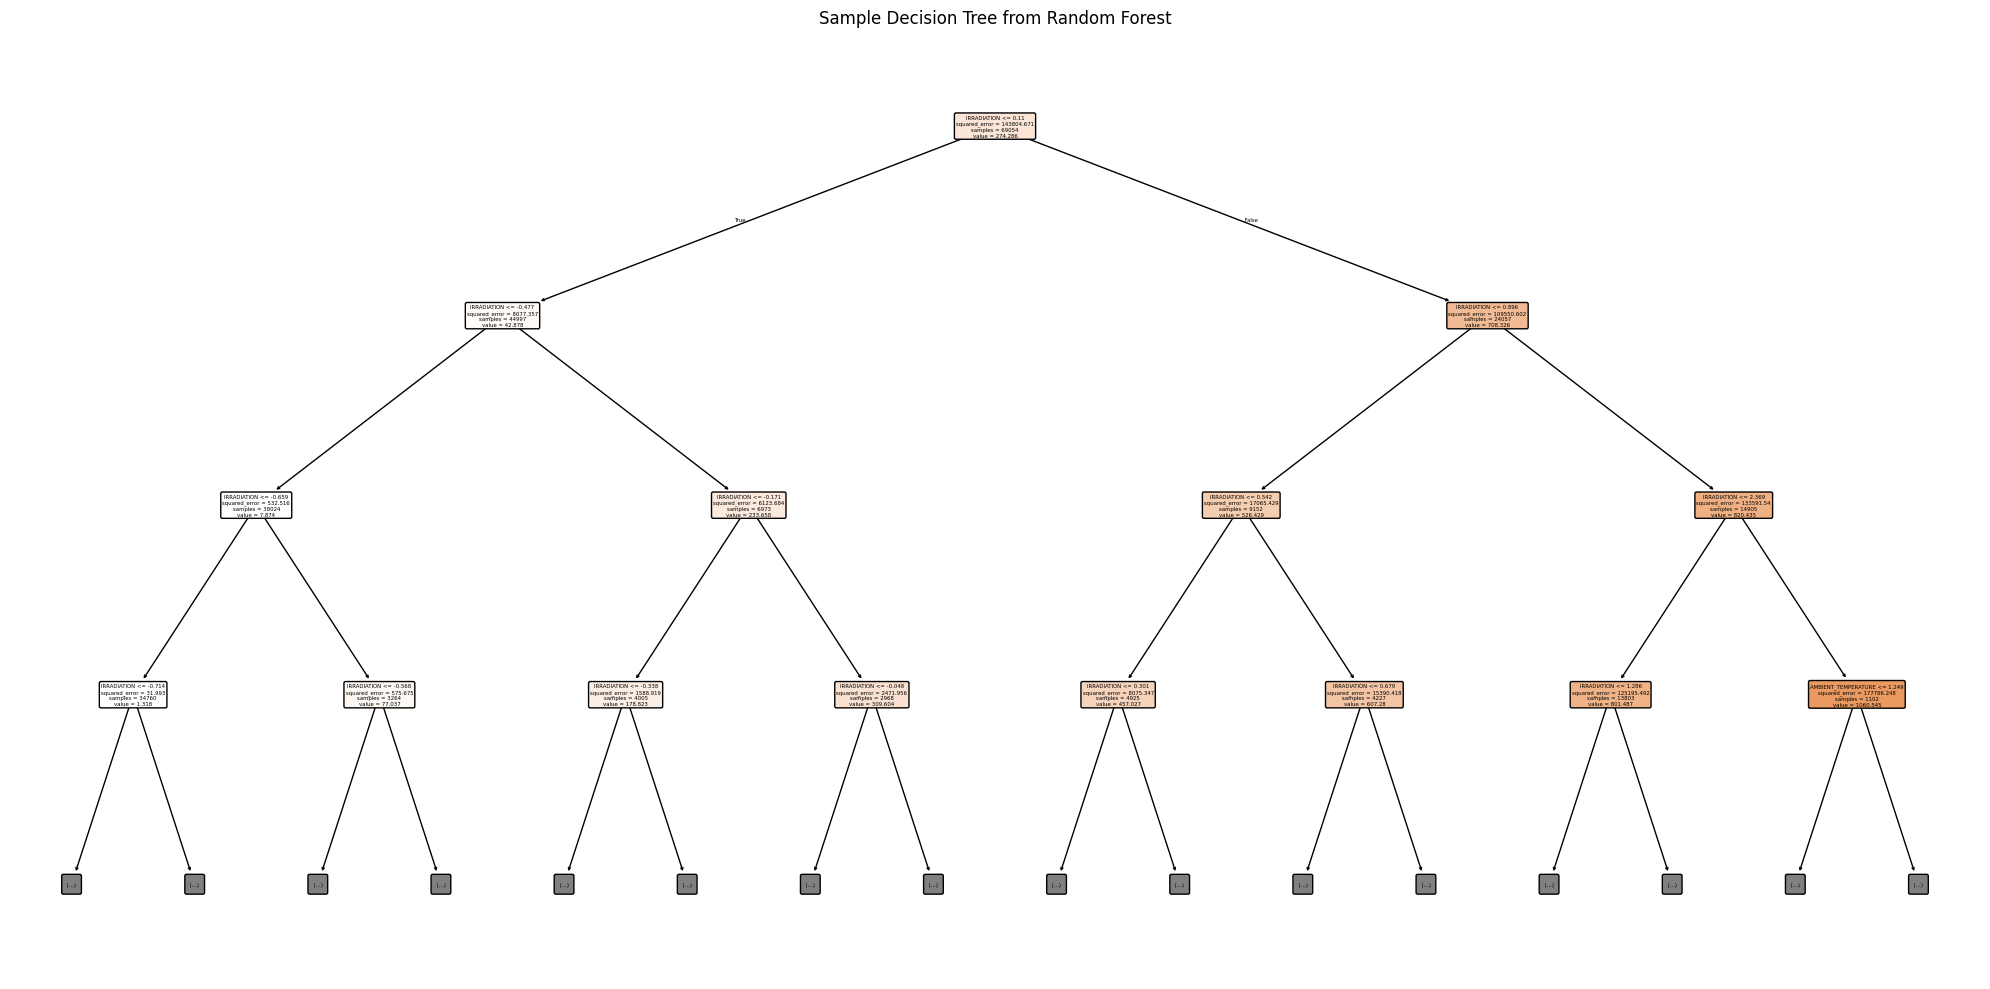

In [19]:
# Add necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Assuming your Random Forest model is already trained
# If not, here's how you would train it:
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

# Define feature names
features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']

# 1. Random Forest Feature Importance (built-in)
plt.figure(figsize=(10, 6))
# Sort features by importance
feature_importance = pd.Series(rf_model.feature_importances_, index=features)
feature_importance = feature_importance.sort_values(ascending=False)

# Create bar plot
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Random Forest Feature Importance', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Permutation Importance for Random Forest
plt.figure(figsize=(10, 6))

# Calculate permutation importance
print("Calculating permutation importance for Random Forest...")
perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)

# Sort features by importance
sorted_idx = perm_importance.importances_mean.argsort()

# Plot
plt.boxplot(perm_importance.importances[sorted_idx].T,
            vert=False, labels=np.array(features)[sorted_idx])
plt.title("Random Forest - Permutation Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Correlation matrix of features with target
plt.figure(figsize=(10, 8))
correlation_data = combined_df[features + ['AC_POWER']]
correlation_matrix = correlation_data.corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features with Target', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Feature Importance Table
# Create a summary table of feature importance
importance_table = pd.DataFrame({
    'Feature': features,
    'Importance (Built-in)': rf_model.feature_importances_,
    'Importance (Permutation)': perm_importance.importances_mean
})

# Sort by built-in importance
importance_table = importance_table.sort_values('Importance (Built-in)', ascending=False)

print("\nRandom Forest Feature Importance Summary Table:")
print(importance_table.round(4))

# 5. Save the feature importance results to a CSV file
importance_table.to_csv('rf_feature_importance_results.csv', index=False)
print("Feature importance results saved to 'rf_feature_importance_results.csv'")

# 6. Additional visualization: Feature importance with standard deviation
plt.figure(figsize=(10, 6))
feature_names = np.array(features)
sorted_idx = perm_importance.importances_mean.argsort()
y_pos = np.arange(len(feature_names))

plt.barh(y_pos, perm_importance.importances_mean[sorted_idx],
         xerr=perm_importance.importances_std[sorted_idx])
plt.yticks(y_pos, feature_names[sorted_idx])
plt.title('Random Forest Feature Importance with Standard Deviation')
plt.xlabel('Permutation Importance')
plt.tight_layout()
plt.show()

# 7. Decision path visualization (for understanding feature influence)
# This shows a single decision tree from the random forest to illustrate decision logic
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(rf_model.estimators_[0], feature_names=features,
          filled=True, rounded=True, max_depth=3)
plt.title('Sample Decision Tree from Random Forest')
plt.tight_layout()
plt.show()